# Monte Carlo VaR — Step by Step

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [ ]:
TICKERS = ['AAPL', 'GOOGL', 'MSFT']
WEIGHTS = np.array([0.40, 0.35, 0.25])
PORT_VALUE = 1_000_000
np.random.seed(42)

WEIGHTS

array([0.4 , 0.35, 0.25])

In [27]:
prices = yf.download(TICKERS, start='2023-01-01', end='2026-01-01', auto_adjust=True)['Close'][TICKERS].dropna()
prices.tail()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOGL,MSFT
Date,,,
2025-12-24,273.554016,314.089996,486.908630
2025-12-26,273.144409,313.510010,486.599365
2025-12-29,273.504089,313.559998,485.990753
2025-12-30,272.824707,313.850006,486.369904
2025-12-31,271.605835,313.000000,482.518677


In [28]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.describe().round(4)

Ticker,AAPL,GOOGL,MSFT
count,751.0000,751.0000,751.0000
mean,0.0011,0.0017,0.0010
std,0.0160,0.0190,0.0146
min,-0.0970,-0.0999,-0.0638
25%,-0.0067,-0.0087,-0.0068
50%,0.0013,0.0023,0.0012
75%,0.0087,0.0116,0.0091
max,0.1426,0.0973,0.0965


In [29]:
mu  = log_returns.mean().values
mu

array([0.00105378, 0.00168275, 0.00096676])

In [30]:
cov = log_returns.cov().values
cov

array([[0.00025692, 0.00014008, 0.00011358],
       [0.00014008, 0.00036247, 0.00013643],
       [0.00011358, 0.00013643, 0.00021204]])

In [35]:
S0     = prices.iloc[-1].values
shares = (WEIGHTS * PORT_VALUE) / S0
shares

array([1472.72241061, 1118.21086262,  518.11465968])

In [36]:
sim_returns = np.random.multivariate_normal(mu, cov, size=10_000)
sim_returns.shape

(10000, 3)

In [37]:
sim_prices = S0 * np.exp(sim_returns)
sim_prices[:3]

array([[268.98623474, 310.87375941, 483.01010853],
       [266.65990125, 306.33240488, 473.68121623],
       [269.20598714, 303.56541957, 473.94807854]])

In [38]:
delta_P = sim_prices @ shares - PORT_VALUE
print(f'Mean ΔP: ${np.mean(delta_P):+,.0f}  |  Std: ${np.std(delta_P):,.0f}')

Mean ΔP: $+1,474  |  Std: $13,661


In [39]:
var95 = -np.percentile(delta_P, 5)
print(f'95% VaR = ${var95:,.0f}  ({var95/PORT_VALUE:.2%} of portfolio)')

95% VaR = $21,007  (2.10% of portfolio)


In [40]:
var99 = -np.percentile(delta_P, 1)
print(f'99% VaR = ${var99:,.0f}  ({var99/PORT_VALUE:.2%} of portfolio)')

99% VaR = $29,626  (2.96% of portfolio)


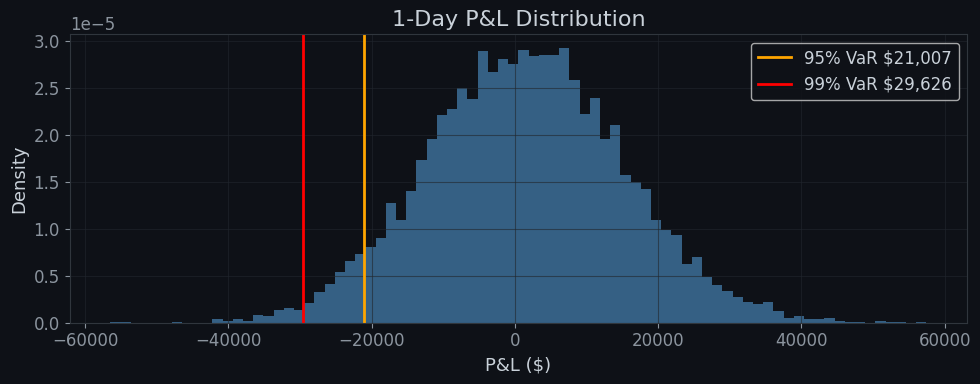

In [43]:
plt.figure(figsize=(10, 4))
plt.hist(delta_P, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='none')
plt.axvline(-var95, color='orange', lw=2, label=f'95% VaR ${var95:,.0f}')
plt.axvline(-var99, color='red', lw=2, label=f'99% VaR ${var99:,.0f}')
plt.xlabel('P&L ($)')
plt.ylabel('Density')
plt.title('1-Day P&L Distribution')
plt.legend()
plt.tight_layout()
plt.show()